<center><h1>Wang_Guanqi_HW2</h1></center>
<br>
<br>

Name: Guanqi Wang
<br>
Github Username: illidanstromrage
<br>
USC ID: 8047294413

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neighbors import KNeighborsRegressor
from tornado.gen import multi
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

Get the Cycle Power Plant Data Set

In [25]:
df = pd.read_excel("./CCPP/Folds5x2_pp.xlsx")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [26]:
df.shape

(9568, 5)

There are 9568 rows and each row represents one hourly observations collected from the CCPP. There are 5 columns representing four hourly average ambient variable: Temperature (AT), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V), to predict the prediction of the net hourly electrical energy output (PE) of the plant

#### ii. pairwise scatterplots of all the varianbles

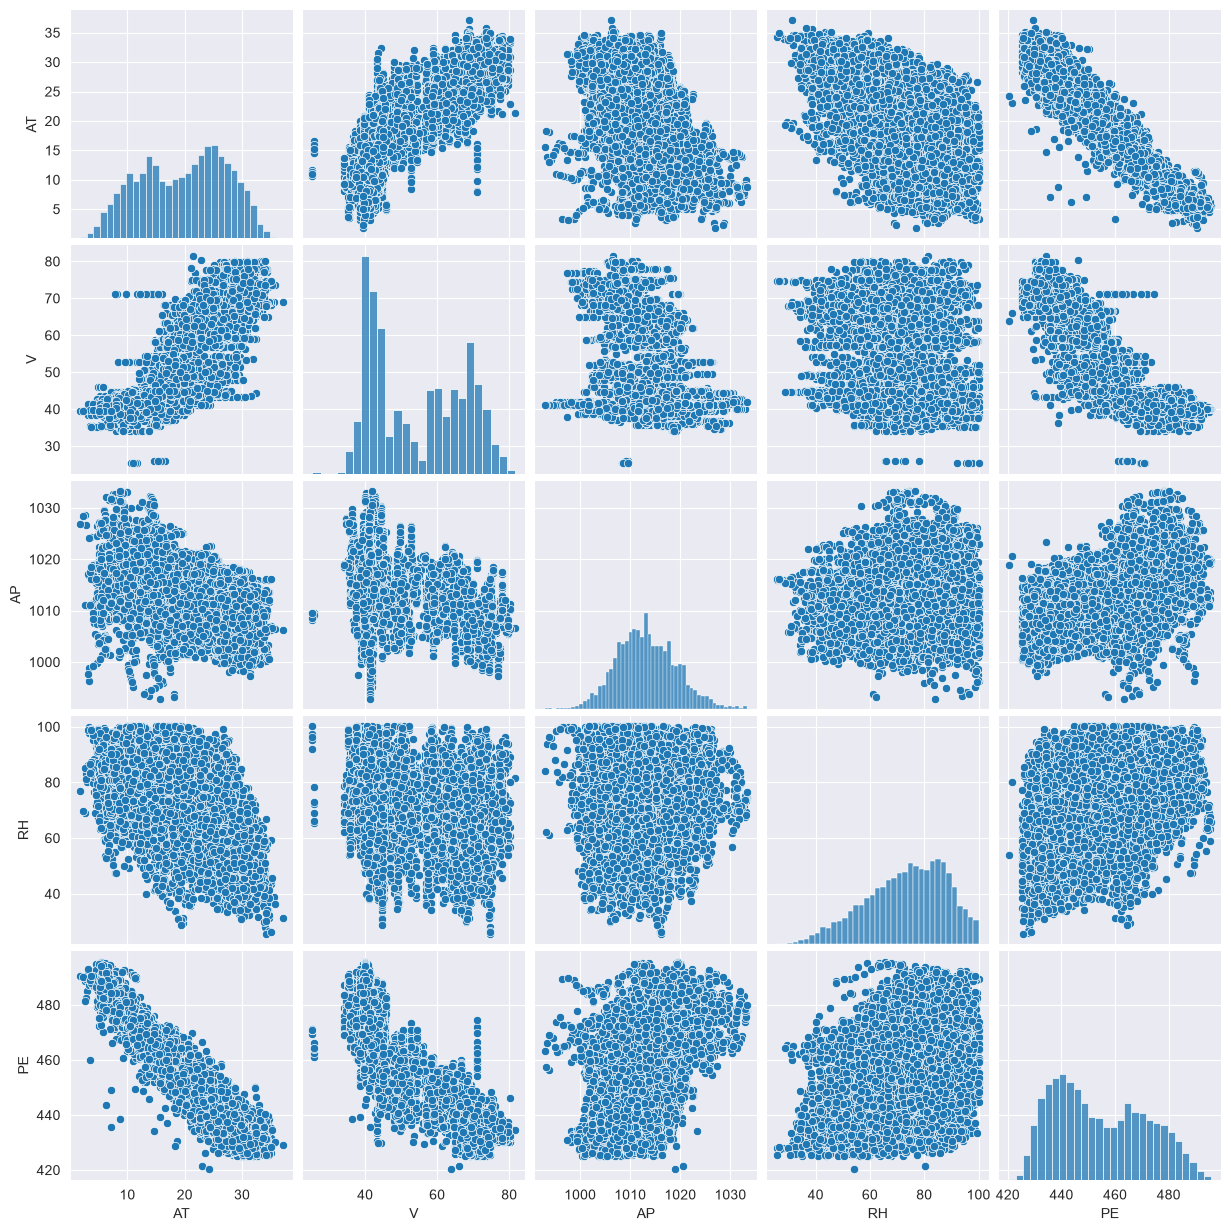

In [27]:
sns.pairplot(df)
plt.show()

First of all, as AT increases, PE drops down. As V increases, PE also drops but the plot shows it is more scattered than AT. When AP goes up the PE tends to increase although judging from the scatter plot, their relationship is much weaker since it is more scattered. For RH it is hard to tell a relationship with PE from the plot because dots are scattering all over the place.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [28]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25),
})

summary


,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### (c) Simple Linear Regression

In [29]:
models = {}
results = []
predictors = ["AT", "V", "AP", "RH"]

for predictor in predictors:
    X = sm.add_constant(df[predictor])
    y = df["PE"]
    model = sm.OLS(y, X).fit()
    models[predictor] = model
    results.append({
        "Predictor": predictor,
        "Coefficients": model.params[predictor],
        "Intercept": model.params["const"],
        "P-value": model.pvalues[predictor],
        "R-squared": model.rsquared
    })
results_df = pd.DataFrame(results)
results_df

,Predictor,Coefficients,Intercept,P-value,R-squared
0,AT,-2.171320,497.034120,0.0,0.898948
1,V,-1.168135,517.801526,0.0,0.756518
2,AP,1.489872,-1055.260989,0.0,0.268769
3,RH,0.455650,420.961766,0.0,0.151939


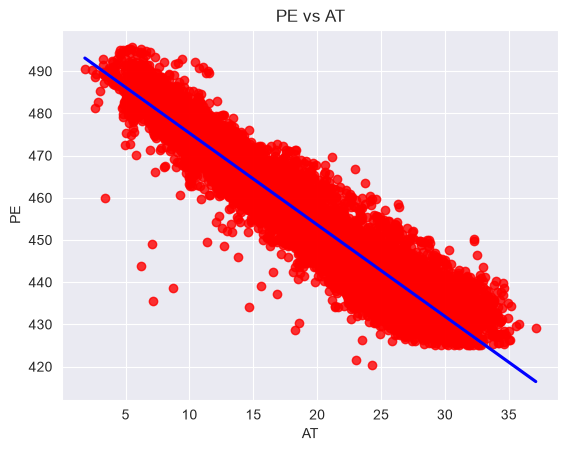

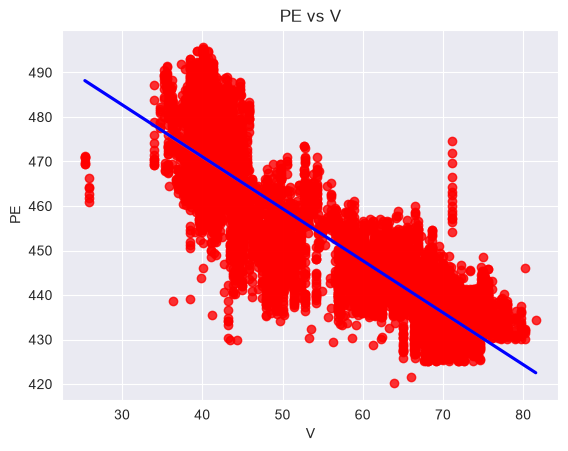

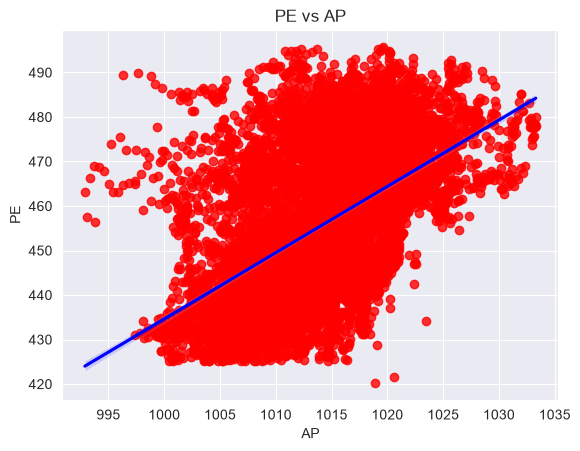

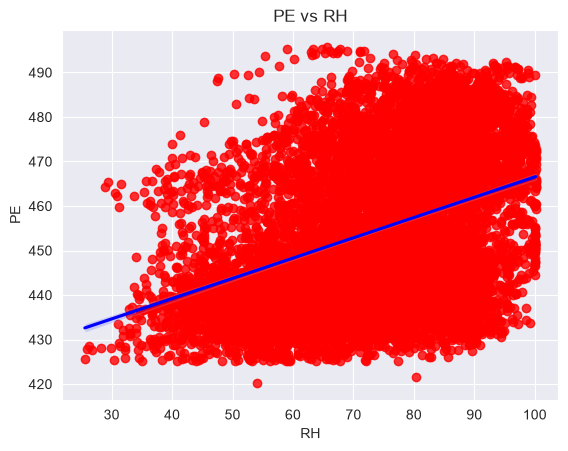

In [30]:
for predictor in predictors:
    sns.regplot(x=predictor, y='PE', data=df, scatter_kws={"color": "red"}, line_kws={"color": "blue"})
    plt.title(f'PE vs {predictor}')
    plt.xlabel(predictor)
    plt.ylabel('PE')
    plt.show()


In [31]:
summary["Lower Bound"] = summary["Q1"] - 1.5* summary["IQR"]
summary["Upper Bound"] = summary["Q3"] + 1.5* summary["IQR"]

for predictor in predictors:
    lower = summary.loc[predictor, "Lower Bound"]
    upper = summary.loc[predictor, "Upper Bound"]

    outliers = df[(df[predictor]<lower) | (df[predictor]>upper)]

    print(predictor, len(outliers), "outliers")

AT 0 outliers
V 0 outliers
AP 88 outliers
RH 12 outliers


For AT and V, we can say there are negative linear relationships with PE based on their negative coefficient on linear regression. AT has the highest R-square value so it has the strongest individual linear relationship with PE. For AP and RH, their p-value are 0 so we can reject the null H proving there is relationship between each individual and PE. Plus their coefficient says they have positive relationship with PE. Nevertheless, their R-square values are relatively low meaning it is very likely that their relationships with PE are not solely on themselves. As for outliers, I adopt the 1.5IQR rule to figure them: under this rule AT&V has 0 outliers while AP has 88 and RH has 12. Each linear model results are presented in above table with regression plots also.

### (d) Multiple Regression

In [32]:
X = df[predictors]
X = sm.add_constant(X)
y = df["PE"]

multi_model = sm.OLS(y, X).fit()
print(multi_model.summary())
print(multi_model.pvalues)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:44:42   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

Here all four predictors have very small p-value, clearly < alpha=0.05, so it is safe to say we can reject null hypothesis for all four of them.

### (e) 1c Compare to 1d

Text(0.5, 1.0, 'Simple vs Multi Coefficient')

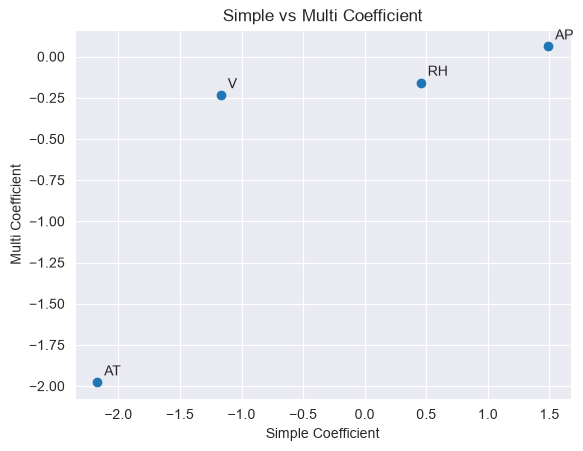

In [33]:
simple_coef = {}
for predictor in predictors:
    simple_coef[predictor] = models[predictor].params[predictor]

multi_coef = multi_model.params[predictors]

coef_df = pd.DataFrame({
    'Predictor': predictors,
    'Simple Coefficient': [simple_coef[predictor] for predictor in predictors],
    'Multi Coefficient': [multi_coef[predictor] for predictor in predictors],
})

# coef_df

plt.scatter(
    coef_df['Simple Coefficient'],
    coef_df['Multi Coefficient'],
)

for i, row in coef_df.iterrows():
    plt.annotate(
        row["Predictor"],
        (row['Simple Coefficient'], row['Multi Coefficient']),
        xytext=(5,5),
        textcoords='offset points',
    )
plt.xlabel('Simple Coefficient')
plt.ylabel('Multi Coefficient')
plt.title('Simple vs Multi Coefficient')

### (f) Nonlinear Association

In [34]:
poly_model = {}
poly_results = []
for predictor in predictors:
    X = df[[predictor]]
    y = df["PE"]

    poly = PolynomialFeatures(degree=3, include_bias=False)
    X_poly = poly.fit_transform(X)

    feature_names = poly.get_feature_names_out([predictor])
    X_poly = pd.DataFrame(X_poly, columns=feature_names, index=df.index)
    X_poly = sm.add_constant(X_poly)
    model = sm.OLS(y, X_poly).fit()
    poly_model[predictor] = model
    # print(model.summary())
    poly_results.append({
        "Predictor": predictor,
        "Linear p-value": model.pvalues[predictor],
        "Squared p-value": model.pvalues[f'{predictor}^2'],
        "Cubic p-value": model.pvalues[f'{predictor}^3'],
        "R-squared": model.rsquared,
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df




C:\Users\XYZ\AppData\Local\Temp\ipykernel_47284\1597053546.py:13: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(y, X_poly).fit()


,Predictor,Linear p-value,Squared p-value,Cubic p-value,R-squared
0,AT,7.898147e-07,8.833045e-73,3.652185e-110,0.911883
1,V,2.526589e-05,7.684969e-01,1.373489e-02,0.775022
2,AP,4.502735e-17,3.666705e-17,8.264146e-18,0.274863
3,RH,3.772510e-04,9.395430e-06,1.440279e-05,0.153743


Judging from all of the p-values from above table, all < 0.05 except V's squared term, we can say that there is evidence of nonlinear association between all four predictors and PE.
Noted for V, the Squared p-value is 0.768 > 0.05 suggesting we may not reject he Null hypothesis, but its cubic p-value suggests the nonlinear association.

### (g) Interactions of Predictors

In [35]:
X = df[predictors]
y = df["PE"]
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)

X_inter = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(predictors)

X_inter = pd.DataFrame(X_inter, columns=feature_names, index=df.index)
X_inter = sm.add_constant(X_inter)
inter_model = sm.OLS(y, X_inter).fit()

print(inter_model.summary())



                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:44:43   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

Here we want to figure the interaction terms, so we only check the last 6 terms and their p-values.
Noted (At, V), (AT, RH), (V, AP), (AP, RH) these four interaction pairs have a p-value < 0,05, which suggest that we reject the Null hypothesis and thus they are statically significant

### (h) Improvement

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_linear = sm.add_constant(X_train)
X_test_linear = sm.add_constant(X_test)

linear_model = sm.OLS(y_train, X_train_linear).fit()
# print(linear_model.summary())
linear_train_pred = linear_model.predict(X_train_linear)
linear_test_pred = linear_model.predict(X_test_linear)

linear_train_mse = mean_squared_error(y_train, linear_train_pred)
linear_test_mse = mean_squared_error(y_test, linear_test_pred)

# print("Linear Train MSE:", linear_train_mse)
# print("Linear Test MSE:", linear_test_mse)

In [37]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
feature_names = poly.get_feature_names_out(predictors)

X_train_poly = pd.DataFrame(X_train_poly, columns=feature_names, index=X_train.index)
X_test_poly = pd.DataFrame(X_test_poly, columns=feature_names, index=X_test.index)
X_train_poly_const = sm.add_constant(X_train_poly)
X_test_poly_const = sm.add_constant(X_test_poly)
poly_model = sm.OLS(y_train, X_train_poly_const).fit()
print(poly_model.summary())

poly_p_value = pd.DataFrame({'P-value': poly_model.pvalues})
poly_p_value

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:44:43   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7664.9809   1429.568     -5.362      0.0

,P-value
const,8.518151e-08
AT,4.460633e-02
V,2.671816e-01
AP,9.534685e-09
RH,1.429286e-04
AT^2,5.017196e-07
AT V,3.195237e-03
AT AP,1.966307e-01
AT RH,3.056335e-03
V^2,6.998020e-01


Here we consider terms with p-value > 0.05 as insignificant and subject to remove. After simple sorting, we can see five terms that are insignificant. But noted even though V is insignificant here, the interaction term (AT, V) is significant and thus we cannot remove it. All other four terms are order of 2 so we will start to remove the one with highest p-value and recalculate everything and repeat.

In [38]:
target_features = ['V RH', 'V^2', 'V AP', 'AT AP']
selected_features = list(feature_names)

while target_features:
    remove = target_features[0]
    print("Removing ", remove)
    selected_features.remove(remove)
    target_features.remove(remove)

    X_temp = sm.add_constant(X_train_poly[selected_features])
    model = sm.OLS(y_train, X_temp).fit()
    max_p = model.pvalues[target_features].max()
    if max_p <= 0.05:
        break

X_train_poly_final = sm.add_constant(X_train_poly[selected_features])
X_test_poly_final = sm.add_constant(X_test_poly[selected_features])
poly_final_model = sm.OLS(y_train, X_train_poly_final).fit()
# print(final_model.summary())

poly_train_pred = poly_final_model.predict(X_train_poly_final)
poly_test_pred = poly_final_model.predict(X_test_poly_final)
poly_train_mse = mean_squared_error(y_train, poly_train_pred)
poly_test_mse = mean_squared_error(y_test, poly_test_pred)
print("Poly improved Train MSE: ", poly_train_mse)
print("Poly improved Test MSE: ", poly_test_mse)


Removing  V RH
Removing  V^2
Removing  V AP
Poly improved Train MSE:  17.890842773184882
Poly improved Test MSE:  18.660040495058844


In [39]:
comparison = pd.DataFrame({
    'Model': ["Linear", "Improved Polynomial"],
    'Train MSE': [linear_train_mse, poly_train_mse],
    'Test MSE': [linear_test_mse, poly_test_mse],
})
comparison

,Model,Train MSE,Test MSE
0,Linear,20.580840,21.239857
1,Improved Polynomial,17.890843,18.660040


Here we finally get the comparison of MSE between simple linear regression and Polynomial plus interaction with improvement from removing three insignificant terms. The test comparison shows Improved Polynomial model MSE < Linear model MSE, which suggests our nonlinearities and interactions is better here.

### (i) KNN

In [40]:
k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    raw_train_mse.append(mean_squared_error(y_train, train_pred))
    raw_test_mse.append(mean_squared_error(y_test, test_pred))

best_k = k_values[np.argmin(raw_test_mse)]

print("Best k for Raw features is: ", best_k)
print("Best Test MSE: ", min(raw_test_mse))
print("Best Train MSE: ", raw_train_mse[best_k-1])

Best k for Raw features is:  5
Best Test MSE:  15.726819842563568
Best Train MSE:  10.600768887561596


In [41]:
scaler = StandardScaler()

X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

norm_train_mse = []
norm_test_mse = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_norm, y_train)
    train_pred = knn.predict(X_train_norm)
    test_pred = knn.predict(X_test_norm)
    norm_train_mse.append(mean_squared_error(y_train, train_pred))
    norm_test_mse.append(mean_squared_error(y_test, test_pred))

best_k_norm = k_values[np.argmin(norm_test_mse)]
best_norm_test_mse = min(norm_test_mse)
best_train_norm_mse = norm_test_mse[best_k_norm-1]
print("Best k for Normalized features is: ", best_k_norm)
print("Best Test MSE: ", best_norm_test_mse)
print("Best Train MSE: ", best_train_norm_mse)


Best k for Normalized features is:  4
Best Test MSE:  14.305669422675024
Best Train MSE:  14.305669422675024


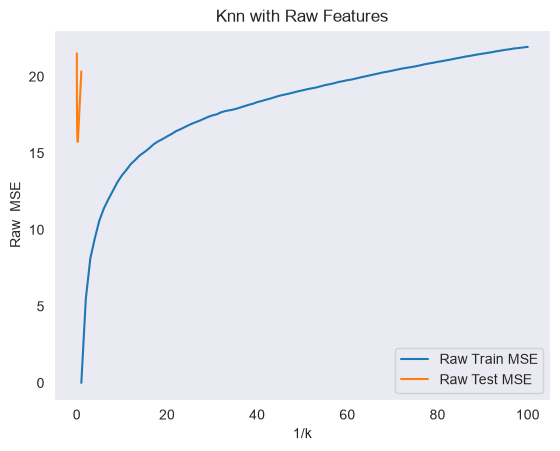

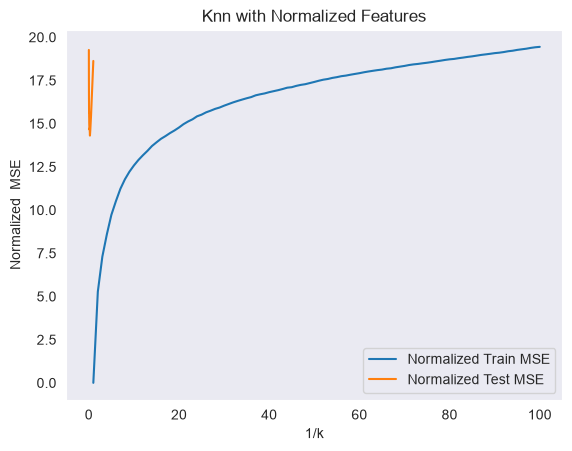

In [42]:
inv_k = 1/np.array(list(k_values))

plt.plot(
    k_values,
    raw_train_mse,
    label="Raw Train MSE",
)
plt.plot(
    inv_k,
    raw_test_mse,
    label="Raw Test MSE",
)
plt.xlabel("1/k")
plt.ylabel("Raw  MSE")
plt.title("Knn with Raw Features")
plt.legend()
plt.grid()
plt.show()

plt.plot(
    k_values,
    norm_train_mse,
    label="Normalized Train MSE",
)

plt.plot(
    inv_k,
    norm_test_mse,
    label="Normalized Test MSE",

)
plt.xlabel("1/k")
plt.ylabel("Normalized  MSE")
plt.title("Knn with Normalized Features")
plt.legend()
plt.grid()
plt.show()

### (j ) Compare KNN and Linear

From (h) we already figured Improved Interaction + Quadratic Regression has the best (lowest) MSE, thus we will use it. And from (i) we figured normalized features have the best MSE.

In [43]:
best_linear = "Interaction + Quadratic Regression"
best_knn = f"Normalized KNN (k = {best_k_norm})"

comparison_knn = pd.DataFrame({
    "Model": [best_linear, best_knn],
    "Train MSE": [poly_train_mse, best_train_norm_mse],
    "Test MSE": [poly_test_mse, best_norm_test_mse],

})
comparison_knn

,Model,Train MSE,Test MSE
0,Interaction + Quadratic Regression,17.890843,18.660040
1,Normalized KNN (k = 4),14.305669,14.305669


Here the best KNN regression with normalized features at k=4 achieved a lower test MSE and thus indicates the better predictive performance on unseen observations. This suggests that the relationship between PE and four predictors contains nonlinear factors that KNN regression is able to capture. This result also agree to our previous experiment data suggesting nonlinear interactions and associations between predictors and PE.  On the other hand, the linear regression model does a better job than KNN when presenting interpretable coefficient describing the effect of each predictor

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible method would perform better. Since we have very large n, we have enough information for estimating more complicated model. And large n can reduce the variance problem for flexible learning method. And since p is small, we do not have to deal with large dimensions, so in general we do not need to worry about overfitting issue.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

The flexible method would do worse. Here we have small n and large p, using flexible method would easily fitting the data with a lot of noise, which cause overfitting.

### (c) The relationship between the predictors and response is highly non-linear.

Flexible method would do better. More flexible method here can relatively capture the nonlinear relationship between predictors and response with more accurate.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

Flexible method would do worse. Var is high means there is a lot of random noise in the set. A flexible method would easily include these noise and cause overfitting and high variance.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

D = sqrt[(X1-0)^2 + (X2-0)^2 + (X3 -0)^2] And we plug in each observation data we get:
D1 = 3, D2 = 2, D3 = sqrt(10), D4=sqrt(5), D5 = sqrt(2), D6 = sqrt(3)

### (b) What is our prediction with K = 1? Why?

For k =1, we only consider the closest neighbor, which is Ob5 with the smallest D. And thus our prediction is with Ob5, which is Green

### (c) What is our prediction with K = 3? Why?

For K=3, now we consider the top 3 closest neighbors sorted by D, which are Ob5=Green, Ob6=Red, and Ob2=Red. And clearly we have two Red and one Green, and thus our prediction for K=3 is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

In this case we want a small K. Because the Bayes decision boundary is highly non-linear, we would want a more flexible method to approximate the complicated relationship. And with KNN regression, more flexible means smaller K where it can produce low bias.